### BNN tutorial
https://arxiv.org/pdf/2304.02595 

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import random
from scipy import stats

# 10 random draws from a standard Gaussian
# distribution - N(0,1)
samples = random.randn(10)
# Gaussian distribution PDF with mean of 4 and 
# standard deviation of 0.5
x = np.linspace(0, 8, 100)
pdf = stats.norm.pdf(x, loc=4, scale=1)


In [25]:
import numpy as np

def metropolis_hastings(Nmax, x0, q, model, likelihood, P, proposal_dist):
    """
    Metropolis-Hastings MCMC sampler.

    Parameters:
    - Nmax: Number of samples to generate
    - x0: Initial sample
    - q: Proposal distribution function q(x)
    - model: The model function f(x, d)
    - likelihood: Likelihood function
    - P: Target distribution P(x)
    - proposal_dist: Proposal distribution function q(x' | x)

    Returns:
    - samples: Generated samples from the posterior distribution
    """
    # Initialize samples array
    samples = np.zeros(Nmax)
    samples[0] = x0
    
    for i in range(1, Nmax):
        # 1. Propose a new sample x' based on current sample xi
        xi = samples[i - 1]
        x_prime = q(xi)  # Propose new sample
        
        # 2. Execute model and compute likelihood
        y_prime = model(x_prime)  # Compute model output for x'
        likelihood_prime = likelihood(y_prime)
        
        # 3. Calculate the acceptance probability alpha
        alpha = min(1, (P(x_prime) * proposal_dist(xi, x_prime)) / (P(xi) * proposal_dist(x_prime, xi)))
        
        # 4. Generate a random uniform value u
        u = np.random.uniform(0, 1)
        
        # 5. Accept or reject the proposed sample
        if u < alpha:
            samples[i] = x_prime  # Accept the new sample
        else:
            samples[i] = xi  # Reject the new sample, retain the old sample

    return samples

# Example usage:
def q(x):
    """Example proposal distribution q(x) - here using a normal distribution."""
    return np.random.normal(x, 1)

def model(x):
    """Example model function f(x, d) - returns x as a placeholder."""
    return x

def likelihood(y):
    """Example likelihood function - simple Gaussian likelihood."""
    return np.exp(-0.5 * y**2)

def P(x):
    """Example target distribution P(x) - here using a standard normal."""
    return np.exp(-0.5 * x**2)

def proposal_dist(x1, x2):
    """Example proposal distribution - here a normal distribution for proposal."""
    return np.exp(-0.5 * (x2 - x1)**2)

# Set parameters
Nmax = 10000  # Number of samples to generate
x0 = 4  # Initial sample

# Run Metropolis-Hastings sampler
samples = metropolis_hastings(Nmax, x0, q, model, likelihood, P, proposal_dist)

# Print or analyze the generated samples
print(samples[:10])  # Print the first 10 samples as a sample output


[4.         3.49160199 3.49160199 2.31024721 2.73478062 2.73478062
 1.62890224 1.29446868 0.90945258 0.60955027]


In [ ]:
import numpy as np
import random
from scipy import stats

# First define our likelihood function which will be dependent on the provided ‘data’.
# In this case we choose k = 50, n = 100.
def likelihood(query_prob):
    """
    Evaluates the probability of observing exactly k successes in n trials,
    given a success probability of query_prob.
    
    Parameters:
        query_prob (float): The probability of success (between 0 and 1).
    
    Returns:
        float: The likelihood computed using the binomial probability mass function.
    """
    k = 50
    n = 100
    return stats.binom.pmf(k, n, query_prob)

# MCMC Settings and Setup
n_samples = 10000  # number of samples to draw from the posterior
burn_in = 2500     # number of samples to discard before recording draws from the posterior

# Initialize a value of x0 by sampling uniformly between 0 and 1
x = random.uniform(0, 1)

# Create an array of NaNs to fill with our samples
p_posterior = np.full(n_samples, np.nan)

print("Generating {} MCMC samples from the posterior:".format(n_samples))

# MCMC Sampling loop
for ii in np.arange(n_samples):
    # Sample a value uniformly from 0 to 1 as a proposal
    x_new = random.uniform(0, 1)
    
    # For this example, the prior is uniform so the prior ratio is 1.
    prior_ratio = 1
    
    # Compute the likelihood ratio of the proposed value vs. the current value
    likelihood_ratio = likelihood(x_new) / likelihood(x)
    
    # Calculate the Metropolis–Hastings acceptance probability
    alpha = min(1, likelihood_ratio * prior_ratio)
    
    # Draw a random value from uniform[0,1] to decide whether to accept the proposal
    u = random.uniform(0, 1)
    if u < alpha:
        x = x_new  # Accept the proposal
    
    # Store the current sample (whether updated or not)
    p_posterior[ii] = x

# Optionally, discard burn-in samples:
p_posterior = p_posterior[burn_in:]

# For example, you could print or analyze the posterior samples:
print("Mean of the posterior samples (after burn-in):", np.mean(p_posterior))


Generating 10000 MCMC samples from the posterior:
Mean of the posterior samples (after burn-in): 0.05911169191041744


(array([4.170e+02, 1.409e+03, 2.263e+03, 2.046e+03, 7.880e+02, 4.170e+02,
        1.330e+02, 8.000e+00, 1.800e+01, 1.000e+00]),
 array([0.01048454, 0.02717396, 0.04386339, 0.06055282, 0.07724225,
        0.09393167, 0.1106211 , 0.12731053, 0.14399996, 0.16068939,
        0.17737881]),
 <BarContainer object of 10 artists>)

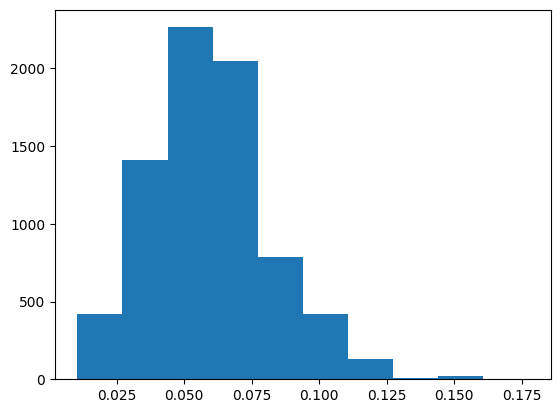

In [38]:
plt.hist(p_posterior)

In [40]:
import numpy as np
import pandas as pd

# ------------------------------
# Linear Model
# ------------------------------
class LinearModel:
    def __init__(self):
        self.w = None  # weights
        self.b = None  # bias

    def evaluate_proposal(self, data, theta):
        """
        Given a parameter vector theta, split it into weights and bias,
        then predict the output for the provided data.
        
        Parameters:
            data (np.ndarray): (N x M) input features.
            theta (np.ndarray): (M+1,) parameter vector (last element is bias).
        
        Returns:
            np.ndarray: Predictions for the input data.
        """
        self.encode(theta)
        return self.predict(data)

    def predict(self, x_in):
        """
        Predict the output using a linear model.
        
        Parameters:
            x_in (np.ndarray): (N x M) input features.
        
        Returns:
            np.ndarray: (N,) predicted output.
        """
        return x_in.dot(self.w) + self.b

    def encode(self, theta):
        """
        Split the parameter vector into weights and bias.
        
        Parameters:
            theta (np.ndarray): (M+1,) parameter vector.
        """
        self.w = theta[:-1]
        self.b = theta[-1]


# ------------------------------
# MCMC Sampler for the Linear Model
# ------------------------------
class MCMC:
    def __init__(self, n_samples, n_burnin, x_data, y_data):
        """
        Parameters:
            n_samples (int): Total number of MCMC samples.
            n_burnin (int): Number of samples to discard (burn-in period).
            x_data (np.ndarray): Input data of shape (N x M).
            y_data (np.ndarray): Observed outputs of shape (N,).
        """
        self.n_samples = n_samples
        self.n_burnin = n_burnin
        self.x_data = x_data
        self.y_data = y_data
        self.theta_size = x_data.shape[1] + 1  # M weights + 1 bias

        # Sampler hyperparameters (step sizes for random walk)
        self.step_theta = 0.02
        self.step_eta = 0.01  # used in the log-space of tau^2

        # Hyperparameters for the priors
        self.sigma_squared = 5   # variance for theta prior
        self.nu_1 = 0            # inverse gamma parameter for tau^2
        self.nu_2 = 0

        # Initialise the linear model
        self.model = LinearModel()

        # To store posterior samples and diagnostics
        self.pos_theta = None
        self.pos_tau = None
        self.rmse_data = None

    @staticmethod
    def rmse(pred, true):
        """Root Mean Squared Error."""
        return np.sqrt(np.mean((pred - true) ** 2))

    def likelihood_function(self, theta, tausq):
        """
        Calculate the log-likelihood of the data given the parameters.
        
        Parameters:
            theta (np.ndarray): (M+1,) parameter vector.
            tausq (float): Variance of the noise term.
        
        Returns:
            log_likelihood (float): Log likelihood.
            model_prediction (np.ndarray): Predictions of the model.
            accuracy (float): RMSE of the prediction.
        """
        model_prediction = self.model.evaluate_proposal(self.x_data, theta)
        accuracy = self.rmse(model_prediction, self.y_data)
        # Assuming Gaussian noise:
        log_likelihood = np.sum(
            -0.5 * np.log(2 * np.pi * tausq) - 0.5 * ((self.y_data - model_prediction) ** 2) / tausq
        )
        return log_likelihood, model_prediction, accuracy

    def prior(self, sigma_squared, nu_1, nu_2, theta, tausq):
        """
        Calculate the log prior probability of the parameters.
        
        Parameters:
            sigma_squared (float): Variance of the Gaussian prior for theta.
            nu_1 (float): Inverse gamma parameter nu_1 for tausq.
            nu_2 (float): Inverse gamma parameter nu_2 for tausq.
            theta (np.ndarray): (M+1,) parameter vector.
            tausq (float): Variance of the noise term.
        
        Returns:
            log_prior (float): Log prior probability.
        """
        n_params = self.theta_size
        part1 = - (n_params / 2) * np.log(sigma_squared)
        part2 = np.sum(np.square(theta)) / (2 * sigma_squared)
        log_prior = part1 - part2 - (1 + nu_1) * np.log(tausq) - (nu_2 / tausq)
        return log_prior

    def sampler(self):
        """
        Run the Metropolis–Hastings MCMC sampler.
        
        Returns:
            results_df (pd.DataFrame): Posterior samples and diagnostics.
        """
        # Pre-allocate arrays to store samples and diagnostics.
        pos_theta = np.ones((self.n_samples, self.theta_size))
        pos_tau = np.ones((self.n_samples, 1))
        pred_y = np.ones((self.n_samples, self.x_data.shape[0]))
        rmse_data = np.zeros(self.n_samples)

        # --- Initialization ---
        theta = np.random.randn(self.theta_size)
        pred_y[0, :] = self.model.evaluate_proposal(self.x_data, theta)
        eta = np.log(np.var(pred_y[0, :] - self.y_data))
        tausq_proposal = np.exp(eta)

        prior_val = self.prior(self.sigma_squared, self.nu_1, self.nu_2, theta, tausq_proposal)
        likelihood, pred_y[0, :], rmse_data[0] = self.likelihood_function(theta, tausq_proposal)

        # --- MCMC Sampling Loop ---
        for ii in range(1, self.n_samples):
            # Propose new theta and eta (log tau^2) via Gaussian random walk.
            theta_proposal = theta + np.random.normal(0, self.step_theta, self.theta_size)
            eta_proposal = eta + np.random.normal(0, self.step_eta, 1)
            tausq_proposal = np.exp(eta_proposal)

            prior_proposal = self.prior(self.sigma_squared, self.nu_1, self.nu_2, theta_proposal, tausq_proposal)
            likelihood_proposal, pred_y[ii, :], rmse_data[ii] = self.likelihood_function(theta_proposal, tausq_proposal)

            # Compute acceptance probability.
            diff_likelihood = likelihood_proposal - likelihood
            diff_prior = prior_proposal - prior_val
            mh_prob = min(1, np.exp(diff_likelihood + diff_prior))

            # Accept or reject the proposal.
            u = np.random.uniform(0, 1)
            if u < mh_prob:
                likelihood = likelihood_proposal
                prior_val = prior_proposal
                theta = theta_proposal
                eta = eta_proposal

            # Store current state.
            pos_theta[ii, :] = theta
            pos_tau[ii, :] = np.exp(eta)

        # Discard burn-in samples.
        self.pos_theta = pos_theta[self.n_burnin:, :]
        self.pos_tau = pos_tau[self.n_burnin:, :]
        self.rmse_data = rmse_data[self.n_burnin:]

        # Organise results into a DataFrame.
        results_dict = {
            **{"w{}".format(i): self.pos_theta[:, i] for i in range(self.theta_size - 1)},
            "b": self.pos_theta[:, -1],
            "tau": self.pos_tau.squeeze(),
            "rmse": self.rmse_data.squeeze()
        }
        results_df = pd.DataFrame(results_dict)
        return results_df

    def model_draws(self, num_samples=10):
        """
        Simulate new model predictions (mu) by drawing parameters from the posterior,
        assuming the posterior distributions are approximately Gaussian.
        
        Parameters:
            num_samples (int): Number of model draws.
        
        Returns:
            pred_y (np.ndarray): Predicted outputs for each draw.
            sim_y (np.ndarray): Simulated outputs for each draw.
        """
        pred_y = np.zeros((num_samples, self.x_data.shape[0]))
        sim_y = np.zeros((num_samples, self.x_data.shape[0]))
        for ii in range(num_samples):
            theta_drawn = np.random.normal(self.pos_theta.mean(axis=0), self.pos_theta.std(axis=0), self.theta_size)
            tausq_drawn = np.random.normal(self.pos_tau.mean(), self.pos_tau.std())
            # Use the likelihood function to get predictions.
            _, pred_y[ii, :], _ = self.likelihood_function(theta_drawn, tausq_drawn)
            # Here, sim_y is taken to be the same as pred_y; you could add extra noise if desired.
            sim_y[ii, :] = pred_y[ii, :]
        return pred_y, sim_y


# ------------------------------
# Main Execution
# ------------------------------
if __name__ == '__main__':
    # MCMC settings
    n_samples = 20000
    burn_in = int(n_samples * 0.25)

    # Generate toy data
    n_data = 100
    n_features = 1
    x_data = np.linspace(0, 1, n_data).reshape(-1, n_features)
    # True model: y = 3 * x + 4 plus Gaussian noise
    y_data = 3 * x_data[:, 0] + 4 + np.random.randn(n_data) * 0.5

    # Initialise and run the MCMC sampler
    mcmc = MCMC(n_samples, burn_in, x_data, y_data)
    results = mcmc.sampler()
    print("Posterior sample summary:")
    print(results.head())

    # Draw sample model predictions from the posterior
    pred_y, sim_y = mcmc.model_draws(num_samples=100)
    print("Drawn model predictions shape:", pred_y.shape)


Posterior sample summary:
         w0         b       tau      rmse
0  2.804083  4.048593  0.256007  0.469767
1  2.813683  4.060442  0.255527  0.466473
2  2.803858  4.060852  0.258811  0.467131
3  2.804884  4.024799  0.256833  0.471035
4  2.824617  4.020037  0.255620  0.469631
Drawn model predictions shape: (100, 100)


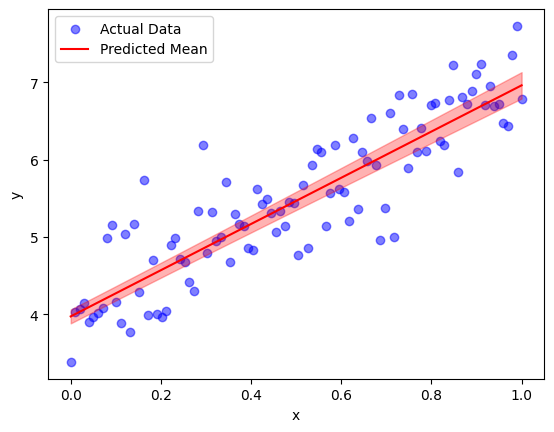

In [44]:
import matplotlib.pyplot as plt

# Get the mean prediction from the sampled models
mean_pred = pred_y.mean(axis=0)

# Plot actual data
plt.scatter(x_data[:, 0], y_data, label="Actual Data", color="blue", alpha=0.5)

# Plot predicted mean
plt.plot(x_data[:, 0], mean_pred, label="Predicted Mean", color="red")

# Optional: Add uncertainty bounds (e.g., ±1 std deviation)
std_pred = pred_y.std(axis=0)
plt.fill_between(x_data[:, 0], mean_pred - std_pred, mean_pred + std_pred, color="red", alpha=0.3)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()
